# I. Project Information
Notebook: 01 - Cong Caphe Metadata

# II. Notebook Objectives

# III. Notebook Setup

## III.A. Import Libraries

In [2]:
import yaml
import json
import warnings
import requests
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from bs4 import BeautifulSoup

# Python warning ignore
warnings.filterwarnings('ignore')

# Set pandas display options to show all columns and rows
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

## III.B. Import Global Config

In [ ]:
# Loading Global Config

PROJECT_ROOT = Path.cwd().parent

def load_config():
    config_path = PROJECT_ROOT / "configs" / "paths.yaml"
    with open(config_path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)

config = load_config()

## III.C. Import URL

In [3]:
# Loading Url

url = "https://congcaphe.com"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}

In [19]:
metadata = {
  "page_url": url,
  "page_title": None,
  "page_type": None,
  "page_author": None,
  "meta_keywords": None,
  "meta_description": None,
}

# IV. Cong CaPhe Metadata

## IV.A. Fetch HTML Content

<!DOCTYPE html><html lang="en"><head><link data-react-helmet="true" rel="shortcut icon" type="image/png" href=""/><meta data-react-helmet="true" property="og:site_name" content="Cộng Cà Phê"/><meta data-react-helmet="true" property="og:locale" content="vi_VN"/><meta data-react-helmet="true" property="twitter:card" content="summary_large_image"/><meta data-react-helmet="true" property="og:title" content="Home"/><meta data-react-helmet="true" property="og:description" content=""/><meta data-react-helmet="true" property="og:image" content=""/><meta data-react-helmet="true" property="og:url" content="congcaphe.com/"/><meta data-react-helmet="true" property="og:type" content="article"/><meta data-react-helmet="true" property="twitter:title" content="Home"/><meta data-react-helmet="true" property="twitter:description" content=""/><meta data-react-helmet="true" property="twitter:image" content=""/><title data-react-helmet="true">Cộng Cà Phê</title><script src="/static/jquery-1.9.1.min.js"></s
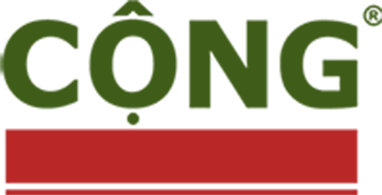
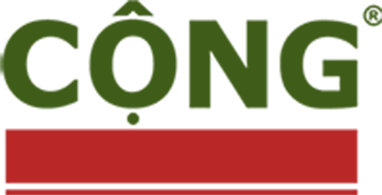

In [5]:
# Fetch HTML content from the Url

def fetch_html(url: str) -> str:
    try:
        response = requests.get(url, headers=headers)
        response.raise_for_status()
        return response.text
    except requests.exceptions.RequestException as e:
        print(f"Error fetching url {url}: {e}")
        return ""

html = fetch_html(url)
print(html)

## IV.B. Parse HTML Content

<!DOCTYPE html>
<html lang="en">
 <head>
  <link data-react-helmet="true" href="" rel="shortcut icon" type="image/png"/>
  <meta content="Cộng Cà Phê" data-react-helmet="true" property="og:site_name"/>
  <meta content="vi_VN" data-react-helmet="true" property="og:locale"/>
  <meta content="summary_large_image" data-react-helmet="true" property="twitter:card"/>
  <meta content="Home" data-react-helmet="true" property="og:title"/>
  <meta content="" data-react-helmet="true" property="og:description"/>
  <meta content="" data-react-helmet="true" property="og:image"/>
  <meta content="congcaphe.com/" data-react-helmet="true" property="og:url"/>
  <meta content="article" data-react-helmet="true" property="og:type"/>
  <meta content="Home" data-react-helmet="true" property="twitter:title"/>
  <meta content="" data-react-helmet="true" property="twitter:description"/>
  <meta content="" data-react-helmet="true" property="twitter:image"/>
  <title data-react-helmet="true">
   Cộng Cà Phê
  </ti
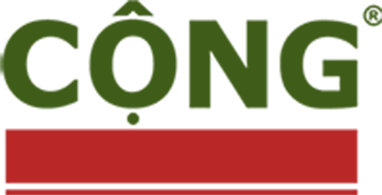
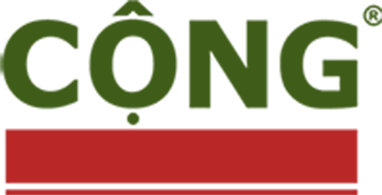

In [6]:
# Parse HTML content using BeautifulSoup

def parse_html(html: str) -> BeautifulSoup:
    soup = BeautifulSoup(html, "html.parser")
    return soup

soup = parse_html(html)
print(soup.prettify())

## IV.C. Extract HTML Content

In [24]:
# Extract metadata from the parsed HTML content

def extract_metadata(soup: BeautifulSoup, url: str) -> dict:

  title_tag = soup.find("title")
  if title_tag:
    metadata["page_title"] = title_tag.text.strip()

  type_tag = soup.find("meta", attrs={"property": "og:type"})
  if type_tag and "content" in type_tag.attrs:
    metadata["page_type"] = type_tag.get("content")


  author_tag = soup.find("meta", attrs={"name": "author"})
  if author_tag and "content" in author_tag.attrs:
    metadata["page_author"]["author"] = author_tag.get("content")

  keywords_tag = soup.find("meta", attrs={"name": "keywords"})
  if keywords_tag and "content" in keywords_tag.attrs:
    metadata["page_keywords"] = keywords_tag.get("content")

  return metadata

extracted_metadata = extract_metadata(soup, url)
print(json.dumps(extracted_metadata, indent=2, ensure_ascii=False))

{
  "page_url": "https://congcaphe.com",
  "page_title": "Cộng Cà Phê",
  "page_type": "article",
  "page_author": null,
  "meta_keywords": null,
  "meta_description": null
}


## IV.D. Clean HTML Content

# V. Export Dataset

## V.A. Export MetaData to Json

In [ ]:
# Export MetaData to Json Format

def export_to_json():
  return

## V.B. Export MetaData to Yaml

In [ ]:
# Export MetaData to Yaml Format

def export_to_yaml():
  return